# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Kofi Mason
**Student ID:** 87342026

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [35]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

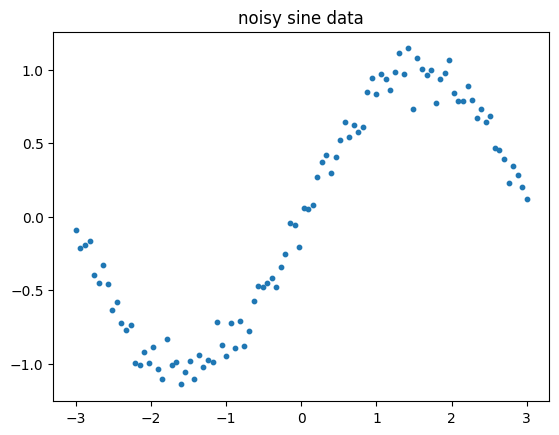

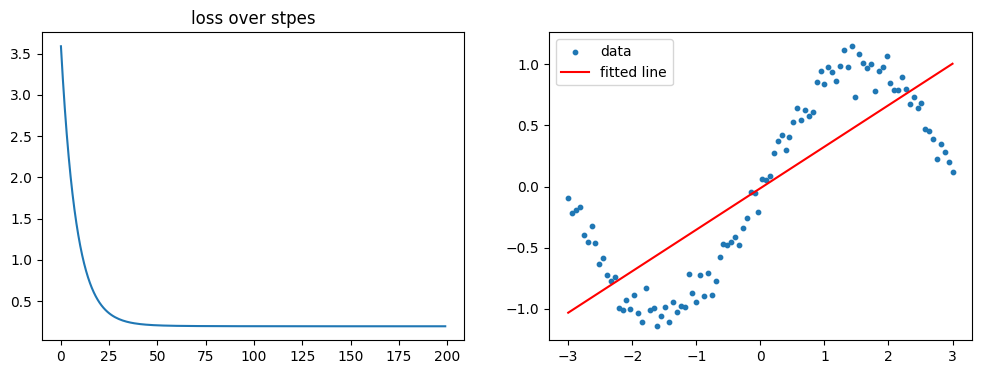

In [36]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size = x.shape)

plt.scatter(x, y, s = 10)
plt.title("noisy sine data")
plt.show()
# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.5
b = np.random.randn() * 0.5
lr = 0.01
losses = []
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
for step in range(200):
  y_hat = w * x + b
  loss = np.mean((y_hat - y) ** 2)
  dw = np.mean(2 * (y_hat - y) * x)
  db = np.mean(2 * (y_hat - y))
  w -= lr * dw
  b -= lr * db
  losses.append(loss)
# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
fig, axes = plt.subplots(1, 2, figsize= (12, 4))
axes[0].plot(losses)
axes[0].set_title("loss over stpes")

axes[1].scatter(x, y, s= 10, label= "data")
axes[1].plot(x, w * x + b, color= "red", label= "fitted line")
axes[1].legend()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** [Double-click to edit]IMG_0670.HEIC

The above shows underfitting. The model is too simple to capture the non-linear sine curve, so even after trainging, the loss stops improving at a value that is still fairly high. A single line can only represent a linear relationship though, while sin(x) is curved, so no amount of training can make a line match it pretty well.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

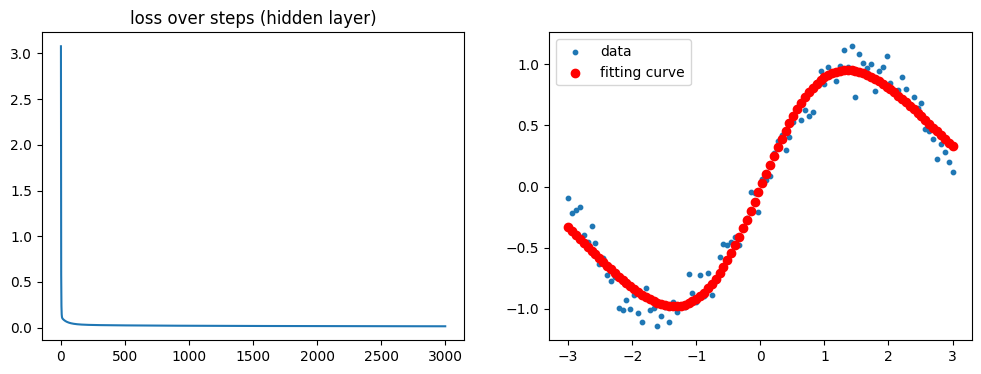

In [37]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
np.random.seed(RANDOM_STATE)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)
lr = 0.05
losses_hidden = []
x_col = x.reshape(-1, 1)
y_col = y.reshape(-1, 1)
# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
for step in range(3000):
  z1 = x_col @ W1 + b1
  h = np.tanh(z1)
  y_hat = h @ W2 + b2

  loss = np.mean((y_hat - y_col)**2)
  losses_hidden.append(loss)

  d_yhat = 2 * (y_hat - y_col) / len(x)

  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis = 0)

  dh = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)

  dW1 = x_col.T @ dz1
  db1 = dz1.sum(axis = 0)

  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
fig, axes = plt.subplots(1, 2, figsize = (12, 4))
axes[0].plot(losses_hidden)
axes[0].set_title("loss over steps (hidden layer)")
# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
axes[1].scatter(x, y, s = 10, label = "data")
axes[1].scatter(x, y_hat, color = "red", label = "fitting curve")
axes[1].legend()
plt.show()


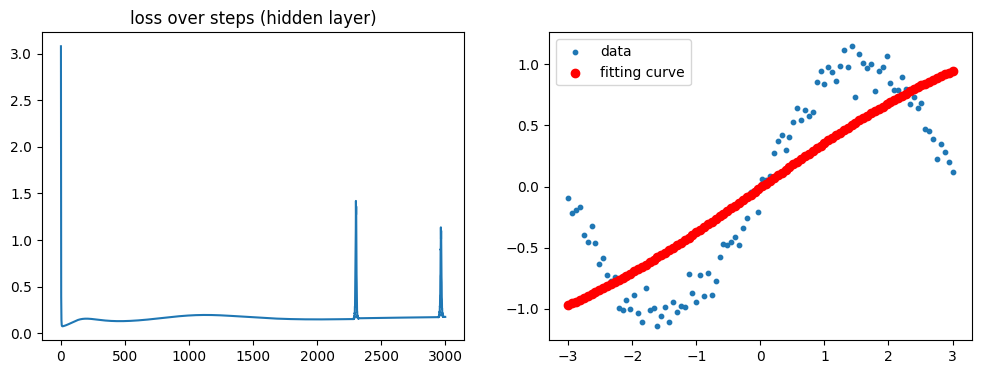

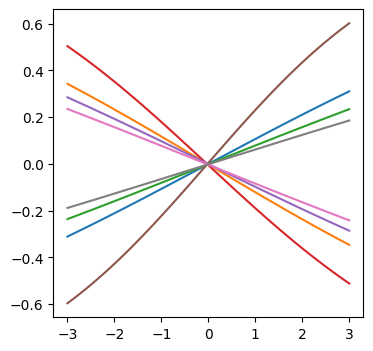

In [38]:
#re-run with the tanh REMOVED (h = z1). What happens to the fit?
np.random.seed(RANDOM_STATE)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)
lr = 0.05
losses_hidden = []
x_col = x.reshape(-1, 1)
y_col = y.reshape(-1, 1)

for step in range(3000):
  z1 = x_col @ W1 + b1
  h = np.tanh(z1)
  y_hat = h @ W2 + b2

  loss = np.mean((y_hat - y_col)**2)
  losses_hidden.append(loss)

  d_yhat = 2 * (y_hat - y_col) / len(x)

  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis = 0)

  dh = d_yhat @ W2.T
  dz1 = dh

  dW1 = x_col.T @ dz1
  db1 = dz1.sum(axis = 0)

  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
axes[0].plot(losses_hidden)
axes[0].set_title("loss over steps (hidden layer)")
axes[1].scatter(x, y, s = 10, label = "data")
axes[1].scatter(x, y_hat, color = "red", label = "fitting curve")
axes[1].legend()
plt.show()
#the fit straightend out and looks almost linear, but it isn't quite.
# it basically looks like the fit for the single-neuron fit in part 1.1.

plt.figure(figsize=(4, 4))
for i in range(8):
    plt.plot(x, h[:, i], label=f"neuron {i}")
plt.show()


**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** [Double-click to edit]

1.

without tanh, the forward pass is simply:

h = x @ W1 + b1

y_hat = h @ W2 + b2

by subbing in h in the second equation, we would get something like this:

y_hat = (x @ W1 + b1) @ W2 + b2

y_hat = (x @ W1) @ W2 + (b1 @ W2) + b2

y_hat = x @ (W1 @ W2) + (b1 @ W2 + b2)

by letting (W1 @ W2) be something like W_combined. (b1 @ W2 + b2) is a bias vector we can call b_combined, therefore:

y_hat = x @ W_combined + b_combined

since y_hat = x @ W_combined + b_combined has the exact same form as a single neuron (y_hat = wx + b), stacking two linear layers adds no extra expressive power, it's the same as a linear layer, it just has different values. this is why removing tanh didn't help the network fit any better than in part 1.1. no matter how many linear layers you stack, the result always goes to a linear or near-linear shape.

2.

each of the 8 hidden neurons applies tanh to a different linear combination of the input, producing differently scaled versions of the input. None match a sine "wave" exactly but the utput layer (W2) combines the 8 non-linear shapes into a single flexible function able to approximate the curve. Single neurons cannot do this.

3.

backpropagation is an algorithm used to train artificial neural networks by reducing prediction error.


### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1111/3565323514.py:17: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_col)**2)
/tmp/ipykernel_1111/3565323514.py:23: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_1111/3565323514.py:24: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1)**2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


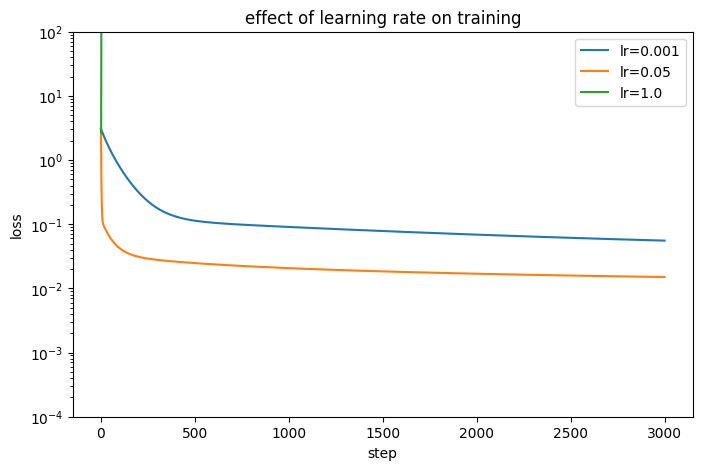

In [39]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps = 3000):
  np.random.seed(RANDOM_STATE)

  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.zeros(8)
  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.zeros(1)
  losses = []

  for step in range(steps):
    z1 = x_col @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y_col)**2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - y_col) / len(x)
    dW2 = h. T @ d_yhat
    db2 = d_yhat.sum(axis = 0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1)**2)
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis = 0)

    W1 -= lr* dW1
    b1 -= lr * db1
    W2 -= lr*dW2
    b2 -= lr * db2

  return losses
# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
losses_low = train_toy(lr = 0.001)
losses_mid = train_toy(lr = 0.05)
losses_high = train_toy(lr = 1.0)
# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8,  5))
plt.plot(losses_low, label="lr=0.001")
plt.plot(losses_mid, label="lr=0.05")
plt.plot(losses_high, label="lr=1.0")
plt.yscale("log")
plt.ylim(1e-4, 1e2)
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("effect of learning rate on training")
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** [Double-click to edit]
1.

with lr = 0.001, the loss decreases very slowly and is still declining at step 3000 which means training hasn't fully converged. With lr = 0.05, the loss drops quickly and at a much lower value. With lr = 1.0, the loss overflows almost instantly and becomes nan. This means training diverged instead of converging.

2.

the learning rate controls how large a step the weights take in the direction the gradient points. A small learning rate takes small steps towards the minimum (albeit slowly). A good learning rate takes big enough steps to converge quickly without overshooting. A too-big learning rate takes steps that are too big and result in kovershooting the minimum. So, because a higher loss produces an even bigger gradient, the next step is even bigger which causes the loss to "explode" rather than settle down. this is why it behaves differently than just learning quicker.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [40]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
df2 = pd.read_csv("https://raw.githubusercontent.com/danielbyiringiro/intro_to_ai_labs/main/Lab2/Obesity_level_prediction_dataset%20(2).csv")
print(df2.shape)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
from sklearn.preprocessing import LabelEncoder, StandardScaler

df2_encoded = df2.copy()   # copy so we don't touch the original dataframe

le = LabelEncoder()
for col in df2_encoded.select_dtypes(include='object').columns:
    df2_encoded[col] = le.fit_transform(df2_encoded[col])


x2 = df2_encoded.drop(columns=['NObeyesdad'])   # features: everything except the target
y2 = df2_encoded['NObeyesdad']                  # target: already integer-encoded by the loop above

# TODO: Stratified train / validation / test split (60/20/20, stratify=y, random_state=RANDOM_STATE)
from sklearn.model_selection import train_test_split

x2_temp, x2_test, y2_temp, y2_test = train_test_split(
    x2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2)   #first split off 20% test

x2_train, x2_val, y2_train, y2_val = train_test_split(
    x2_temp, y2_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y2_temp)  #remaining 80% -> 60/20 train/val

print("train:", x2_train.shape, "val:", x2_val.shape, "test:", x2_test.shape)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
x2_train_scaled = scaler.fit_transform(x2_train)   #fit_transform on train only
x2_val_scaled = scaler.transform(x2_val)            #transform only. reuses train's mean/std
x2_test_scaled = scaler.transform(x2_test)          #same here. the test shouldn't influence the scaler

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train_t = torch.tensor(x2_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y2_train.values, dtype=torch.long)
X_val_t = torch.tensor(x2_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y2_val.values, dtype=torch.long)
X_test_t = torch.tensor(x2_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y2_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)   #shuffle=True only for training
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Ready:", len(train_dataset), "train /", len(val_dataset), "val /", len(test_dataset), "test samples")

(2111, 17)
train: (1266, 16) val: (422, 16) test: (423, 16)
Ready: 1266 train / 422 val / 423 test samples


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** [Double-click to edit]

1.

CrossEntropyLoss expects an integer class label rather than a one-hot vector because the intefger already encodes which class is correct, PyTorch uses it to index directly into the predicted logits. A one-hot vector carries the same info but not as well, so, pytorch's implementation is optimized to take the compact form.

2.

a random forest splits data ising threshold rules which are unaffected by the scale of the input. a threshold works the same whetehr the feeature ranges from 0 to 1 or 0 to 100 or more. Neural networks are different because every gradient formula includes the input value directly from section 1. If one feature jas a much bigger sclae than another, its gradient will be proportionally bigger, causing the optimiser to take unstable steps across features. StandardScale puts every feature on the same scale, so the gradients are balanced and training converges well, and this is why scaling matters more for neural networks than for tree-based models.

3.

shuffle=True randomises the order of training rows, so teh model sees a differnt sequence of batches. This prevents the model from learning false patterns tied to the original row order leading to less biased gradient updates each batch and helping the model generalise better

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [41]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)
class FeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes= (64, 32), n_classes = 7):
    super().__init__()
    layers = []
    prev_size = input_dim

    for hidden_size in hidden_sizes:
      layers.append(nn.Linear(prev_size, hidden_size))
      layers.append(nn.ReLU())
      prev_size = hidden_size

    layers.append(nn.Linear(prev_size, n_classes))

    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)
# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = x2_train.shape[1]
model = FeedForwardNet(input_dim = input_dim, hidden_sizes = (64, 32), n_classes = 7)
model = model.to(DEVICE)
print(model)
# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("total trainable parameters:", n_params)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
first_layer_params = input_dim * 64 + 64
print("expected first layer params:", first_layer_params)


FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
total trainable parameters: 3399
expected first layer params: 1088


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** [Double-click to edit]

1.

Layer 1 (16->64): 16•64 + 64 = 1088 parameters
Layer 2 (64->32): 64•32 + 32 = 2080 parameters
Layer 3 (32->7): 32•7 + 7 = 231 parameters
Total: 1088 + 2080 + 231 = 3399, matching PyTorch's reported count.

2.

ReLU is preferred over tanh in deeper networks because tanh flattens for big positive or negative inputs, making the gradient shrink toward 0; this compiunds across layers during backpropagaztion and causes the vanishing gradient problem. ReLU's gradient is constantly 1 for any positive input, so it doesn't flatten on that side, allowing gradients to go through more layers without vanishing

3.

as shown in part 1.2, stacking linear layers without a nonlinear activation between them collapses into a single linear transformation. without ReLu, this three-layer network would compute the same thing as one linear layer mapping 16 inputs directly to 7 outputs; all the extra layers and parameters would add no additional expressive power.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 1/50 | train_loss: 1.6590 train_acc: 0.5387 | val_loss: 1.5293 val_acc: 0.5735
Epoch 2/50 | train_loss: 1.3453 train_acc: 0.6082 | val_loss: 1.1779 val_acc: 0.6303
Epoch 3/50 | train_loss: 1.0377 train_acc: 0.6485 | val_loss: 0.9491 val_acc: 0.7133
Epoch 4/50 | train_loss: 0.8565 train_acc: 0.7077 | val_loss: 0.8149 val_acc: 0.7393
Epoch 5/50 | train_loss: 0.7393 train_acc: 0.7567 | val_loss: 0.7183 val_acc: 0.7630
Epoch 6/50 | train_loss: 0.6496 train_acc: 0.7930 | val_loss: 0.6399 val_acc: 0.7938
Epoch 7/50 | train_loss: 0.5748 train_acc: 0.8160 | val_loss: 0.5754 val_acc: 0.8152
Epoch 8/50 | train_loss: 0.5090 train_acc: 0.8436 | val_loss: 0.5218 val_acc: 0.8246
Epoch 9/50 | train_loss: 0.4552 train_acc: 0.8633 | val_loss: 0.4779 val_acc: 0.8602
Epoch 10/50 | train_loss: 0.4122 train_acc: 0.8760 | val_loss: 0.4347 val_acc: 0.8744
Epoch 11/50 | train_loss: 0.3698 train_acc: 0.8863 | val_loss: 0.4087 val_acc: 0.8673
Epoch 12/50 | train_loss: 0.3346 train_acc: 0.8965 | val_loss: 

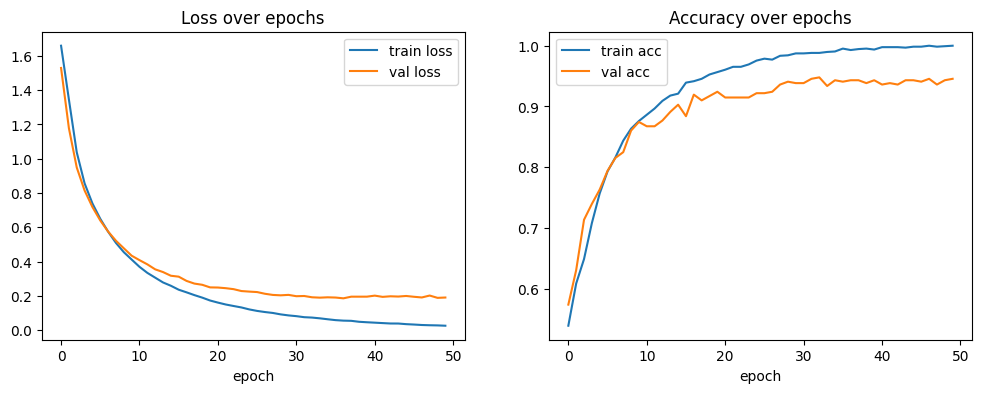

In [45]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0

n_epochs = 50
for epoch in range(n_epochs):


    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)

            val_running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{n_epochs} | train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} | val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), "ffn_best.pt")

print("Best validation accuracy:", best_val_acc)
# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train loss")
axes[0].plot(val_losses, label="val loss")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(train_accs, label="train acc")
axes[1].plot(val_accs, label="val acc")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

1.  

logits = model(xb) is the forward pass; equivalent to the z1, h, y_hat lines in Part 1.2, just computed automatically for however many layers the model has. loss.backward() is the backward pass; equivalent to the dW2, dh, dz1, dW1 chain-rule lines I wrote by hand, but PyTorch's autograd computes them automatically for every parameter in the network. optimizer.step() is the update rule; equivalent to the w -= lr * dw lines, applied to every parameter at once.

2.  

The model is overfitting. Train accuracy reaches about 100% by around epoch 40 to 50, while validation accuracy stops changing around 93 to 94% and never catches up; a persistent 6 to 7 percentage point gap. This is confirmed by the loss curves; train loss keeps decreasing toward 0, while validation loss flattens and slightly increases after epoch 30 or so, even as train loss continues to fall. The model is increasingly fitting quirks specific to the training set rather than patterns that generalize to unseen data

3.

optimizer.zero_grad() clears the gradients from the previous batch before computing new ones. pytorch accumulates gradients by default (adds new gradients to existing ones rather than replacing them), so without zero_grad(), each batch's gradients would pile on top of all prveious batches' gradients within the same epoch. This would silently corrupt training; the optimizer would update weights using an increasingly large, incorrect sum of gradients rather than the current batch's true gradient, with no error thrown to indicate anything is wrong

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

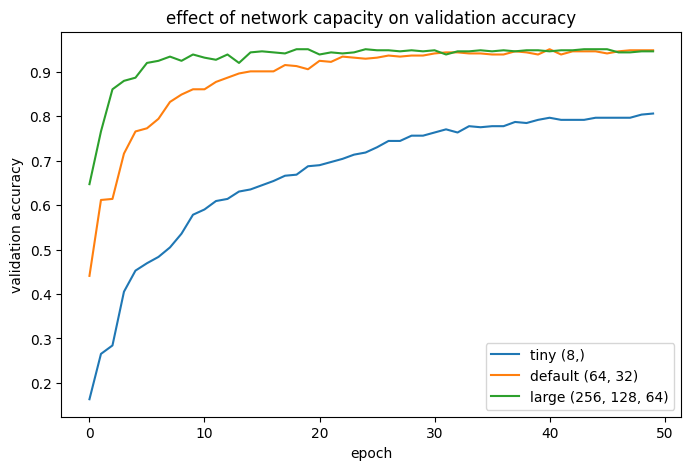

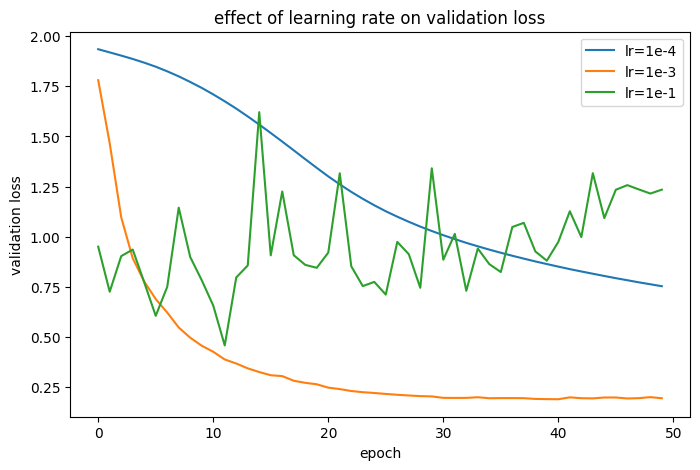

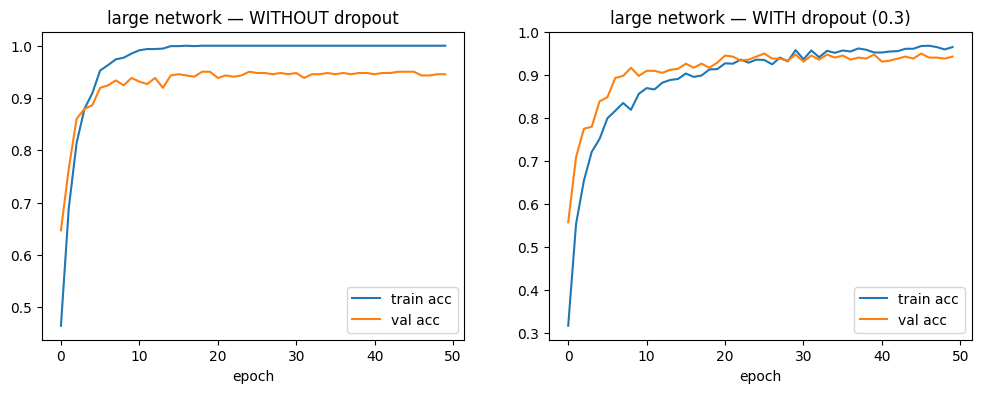

In [53]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    # rebuild the DataLoaders if batch_size changes (reuses the same train/val/test datasets from Part 2.1)
    train_loader_exp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader_exp = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # build a fresh model each time, so experiments don't interfere with each other
    torch.manual_seed(RANDOM_STATE)   # reset seed for a fair comparison across experiments

    layers = []
    prev_size = x2_train.shape[1]
    for hidden_size in hidden_sizes:
        layers.append(nn.Linear(prev_size, hidden_size))
        layers.append(nn.ReLU())
        if dropout > 0:                              # only add Dropout if requested
            layers.append(nn.Dropout(dropout))
        prev_size = hidden_size
    layers.append(nn.Linear(prev_size, 7))

    exp_model = nn.Sequential(*layers).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(exp_model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # ---- training ----
        exp_model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader_exp:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = exp_model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(correct / total)

        # ---- validation ----
        exp_model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader_exp:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = exp_model(xb)
                loss = criterion(logits, yb)

                val_running_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += yb.size(0)

        history["val_loss"].append(val_running_loss / val_total)
        history["val_acc"].append(val_correct / val_total)

    return history
# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
history_tiny = run_experiment(hidden_sizes=(8,))                    # smallest network: 1 hidden layer, 8 neurons
history_default = run_experiment(hidden_sizes=(64, 32))             # same as Part 2.3's architecture
history_large = run_experiment(hidden_sizes=(256, 128, 64))         # largest: 3 hidden layers

# Plot the three validation-accuracy curves together
plt.figure(figsize=(8, 5))
plt.plot(history_tiny["val_acc"], label="tiny (8,)")
plt.plot(history_default["val_acc"], label="default (64, 32)")
plt.plot(history_large["val_acc"], label="large (256, 128, 64)")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("effect of network capacity on validation accuracy")
plt.legend()
plt.show()
# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
history_lr_low = run_experiment(hidden_sizes=(64, 32), lr=1e-4)
history_lr_mid = run_experiment(hidden_sizes=(64, 32), lr=1e-3)
history_lr_high = run_experiment(hidden_sizes=(64, 32), lr=1e-1)

# Plot the three validation-loss curves together
plt.figure(figsize=(8, 5))
plt.plot(history_lr_low["val_loss"], label="lr=1e-4")
plt.plot(history_lr_mid["val_loss"], label="lr=1e-3")
plt.plot(history_lr_high["val_loss"], label="lr=1e-1")
plt.xlabel("epoch")
plt.ylabel("validation loss")
plt.title("effect of learning rate on validation loss")
plt.legend()
plt.show()
# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
history_large_no_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)   # no dropout
history_large_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)      # dropout=0.3 after each hidden layer

# Plot train vs validation accuracy for both runs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_large_no_dropout["train_acc"], label="train acc")
axes[0].plot(history_large_no_dropout["val_acc"], label="val acc")
axes[0].set_title("large network — WITHOUT dropout")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history_large_dropout["train_acc"], label="train acc")
axes[1].plot(history_large_dropout["val_acc"], label="val acc")
axes[1].set_title("large network — WITH dropout (0.3)")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

1.

the largest network did not outperform the defult on validation accuracy; both converged to roughly the same 94 to 95%, with large reaching it slightly faster. the tiny network performed way worse, showing that some minimum capacity is necessary to capture the patterns in the data. Beyond that minimum, however, adding more capacity showed clear diminishing returns.

2.  

yes, the three regimes match part1.3 closely. too small a learning rate caused incomplete convergence in both cases. A good learning rate converged quickly to a low loss in both cases. too large a learning rate caused instability in both; though in part1.3 this fully diverged to nan while here it stayed eratic without fully exploding

3.

dropout significantly narrowed the train-validation gap; without it, train accuracy reached 100% almost immediately while validation plateaued around 94 to 95%, but with dropout the two curves stayed close together throughout training, converging to nearly the same accuracy. Dropout acheives this by randomly zeroing out a fraction of neurons on every forward pass during training, which prevents the network from relying on any single neuron to memorise specific training examples

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test accuracy: 0.9408983451536643
Test macro-F1: 0.9388015308072984

Full classification report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        54
           1       0.89      0.84      0.87        58
           2       0.96      0.99      0.97        70
           3       0.98      0.97      0.97        60
           4       1.00      0.98      0.99        65
           5       0.86      0.86      0.86        58
           6       0.95      0.93      0.94        58

    accuracy                           0.94       423
   macro avg       0.94      0.94      0.94       423
weighted avg       0.94      0.94      0.94       423



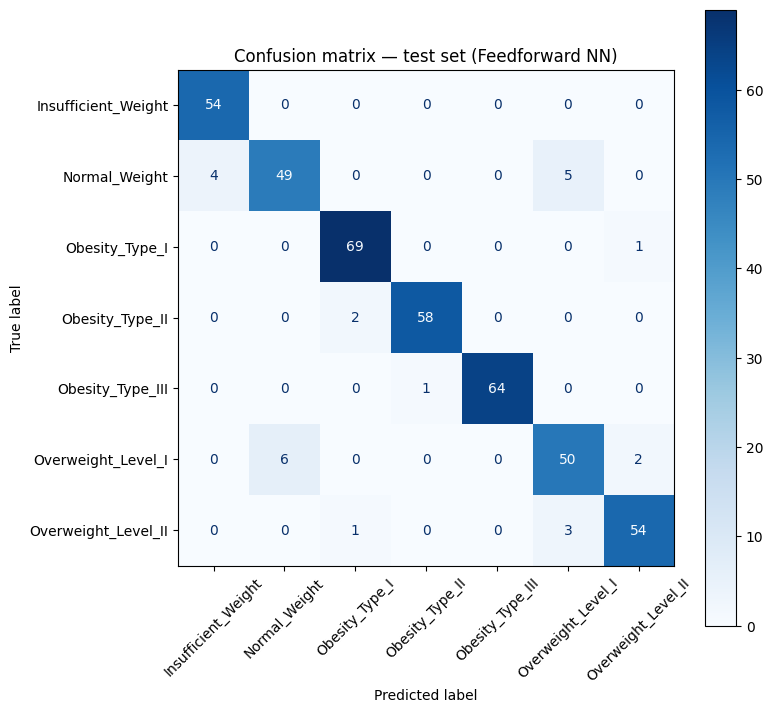

,Model,Test Accuracy,Test Macro-F1
0,Random Forest (Lab 2),0.948000,0.948000
1,Feedforward NN (Lab 3),0.940898,0.938802


In [54]:
# TODO: Load your best configuration's weights; model.eval().
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()
# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import accuracy_score, f1_score, classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average='macro')

print("Test accuracy:", test_acc)
print("Test macro-F1:", test_f1)
print("\nFull classification report:\n", classification_report(all_labels, all_preds))
# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

class_names = le.classes_
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion matrix — test set (Feedforward NN)")
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison_df = pd.DataFrame({
    "Model": ["Random Forest (Lab 2)", "Feedforward NN (Lab 3)"],
    "Test Accuracy": [0.948, test_acc],
    "Test Macro-F1": [0.948, test_f1]
})
comparison_df

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]


1.    

the network confuses classes that are next to each other on the weight pectrum, not distant ones. categories at opposite ends had 0 confusion. this matches the random forest's confusion matrix from lab 2, which showsthe same pattern; near perfect classification of extreme categories, with confusion concentrated among the same middle categories. this confirms the difficulty comes from hoe close these categories are in the underlyiing data, not from a weakness specific to either model

2.

the random forest wins albeit narrowly. given that building the neural network required far more effort for a slightly worse result, deep learning was not worth the extracomplexity on this dataset. this makes sense given the dataset's size and structure. neural networks would likely be worth the added complexity on much larger datasets, on unstructured data like images or text where tree-based models can't operate directly, or on problems with more complex feature interactions than this dataset presents



---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

1.

Three key things happen: (1) loss.backward() uses the chain rule to compute the gradient of the loss with respect to every single parameter in the network, propagating backward from the output layer to the input layer. (2) Each gradient tells the optimizer which direction, and by how much, a small change in that parameter would increase the loss, so moving in the opposite direction reduces it. (3) optimizer.step() then updates every parameter by subtracting a small step in that direction, scaled by the learning rate

2.

i would tune the learning rate first. Across both Section 1  and Section 2, learning rate had the most dramatic impact of any hyperparameter tested. By contrast, network capacity  showed diminishing returns quickly in experiment A. Since a poorly chosen learning rate can prevent the model from learning at all, while other hyperparameters mostly affect how efficiently or how well it learns, learning rate seems like the optimal choice.

3.  

The biggest train-vs-validation gap appeared in the networks without any regularization. Dropout reduced this gap the most; in experiment C, adding dropout kept train and validation accuracy much closer together throughout training, converging to nearly the same value by the end rather than diverging

4.

A plain MLP treats every input feature as independent, with no notion that some features are more related than others. Images break this assumption: neighboring pixels are highly related, and flattening an image into a long list of individual pixel values throws away that spatial structure. a better architecture needs spatial locality and weight sharing (the ability to detect the same local pattern (like an edge or something) regardless of where it appears in the image, using shared filters applied across small neighborhoods rather than treating every pixel as an independent, unrelated input). Convolutional layers provide this.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.